In [31]:
from pybm.convert.probmot import load_library, load_model
import os 


library = load_library("./probmot/AquaticEcosystem.pbl")
incomplete_model = load_model("./probmot/BledIncompleteStructure.pbm", library)

In [32]:
import pandas as pd
from pybm.model import TimeSeries

names = ["00.data", "01.data", "02.data", "95-01.data", "95.data", "96.data", "97.data", "98.data", "99.data"]
dfs = []

# for name in names:
#     df = pd.read_csv("./data/" + name, sep=" ")
#     dfs.append(df)
# df  = pd.concat(dfs, ignore_index=True)

def set_data(filename, model):
    df = pd.read_csv(filename, sep=" ")

    VAR_TO_COLUMN = {
        # eksogene (podatki, ki poganjajo model)
        "ortp.conc": "ortp",              # ortofosfat
        "no.conc": "no",                  # nitrat/dušik
        "silica.conc": "silica",          # silicij
        "daph.conc": "daph_lit",          # dafnija - v teh primerih EKSOGENA (opazovana), ne modelirana
        "env.temperature": "temp",
        "env.light": "light_m",           # NE "light" - uporabljajo "light_m" različico

        # endogena (tarča fita/simulacije)
        "phyto.conc": "phyto",
    }

    t_full = df["t"].values



    for varname, column in VAR_TO_COLUMN.items():
        time_series = TimeSeries(t_full, df[column].values)
        model.vars[varname].data = time_series

# isti dataset kot za probmot, da se lahko primerja z rezultati iz probmot
set_data("./data/96.data", incomplete_model)
t_full = incomplete_model.vars["phyto.conc"].data.t

In [33]:
# get best model 
from pybm.estimate.estimate import estimate_model
#results = estimate_model(incomplete_model, t_eval=t, recepie="gp", verbose=1, max_iter_loss=10, max_gp_iter=50, 
#                         ftol=1e-3, xtol=1e-3, gtol=1e-3, max_nfev=50, collocation_times=collocation_times)

## Hitrejša ocena: `decompose=True`

Zgornja celica reši strukturno dvoumnost s surovo silo: `estimate_model` sprehodi cel Kartezični
produkt vseh odprtih `Choose`/`ChooseProcess` izbir naenkrat. Pri gradient matchingu (`recepie="gp"`)
to ni potrebno - vsaka spremenljivka svojo "trenutno vrednost" ob vsaki časovni točki vedno bere iz
svojega GP-ja, nikoli iz simulacije katere druge spremenljivke, zato je fit konstant za eno
neodvisno strukturno skupino dokazljivo neodvisen od fita za drugo (glej docstring v
`pybm.model_graph`). `estimate_model(..., decompose=True)` to izkoristi: model razdeli na neodvisne
bloke (`pybm.model_graph.build_blocks`) in vsak blok reši posebej, namesto da bi vse kombinacije
množil skupaj - kombinatorična eksplozija (`∏ velikost_izbire`) postane vsota (`Σ velikost_izbire`).

Rezultat je matematično enak (preverjeno s testi, ki `decompose=True` primerjajo z
`decompose=False` na sintetičnih modelih z znano resnico), le hitreje izračunan. Na voljo samo za
`recepie="gp"` (`"gp+ms"`/`"ms"` dejansko simulirata ODE naprej, kar bloke dejansko poveže).

In [34]:
# Ogled blokov, na katere se bo model razdelil - koliko neodvisnih strukturnih iskanj namesto
# enega samega velikega (samo za vpogled, decompose=True to naredi sam)
from pybm.model_graph import build_blocks

for block in build_blocks(incomplete_model):
    state_names = [v.name for v in block.state_vars]
    external_names = [v.name for v in block.external_state_vars]
    print(f"blok {state_names}: {len(block.var_slot_indices)} Choose + "
          f"{len(block.process_slot_indices)} ChooseProcess izbir, bere: {external_names}")

blok ['conc', 'conc', 'conc', 'conc', 'conc']: 0 Choose + 7 ChooseProcess izbir, bere: []


In [ ]:
t = t_full
collocation_times = t[::10]  # every 10th time point for collocation
collocation_times = t[::2] #

# Ista klic kot zgoraj (isti parametri), le z decompose=True - vrne isti tip rezultata
# (FullEstimationResults: best_consts, best_const_by_name, best_loss, all_results)
load = "results_decomp_2026-08-21_14-46-32.pkl"
if load is None:
    results_decomp = estimate_model(
        incomplete_model, t_eval=t, recepie="gp", decompose=True, verbose=1, max_iter_loss=1,
        max_gp_points=1000,
         max_gp_iter=1000, ftol=1e-6, xtol=1e-6, gtol=1e-6, max_nfev=1000, collocation_times=collocation_times,
    )

    print("\nnajboljše konstante (decompose=True):")
    for name, value in results_decomp.best_const_by_name.items():
        print(f"  {name}: {value:.6g}")
    print(f"best_loss: {results_decomp.best_loss:.6g}")
    # save 
    import pickle
    from datetime import datetime

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    with open(f"results_decomp_{timestamp}.pkl", "wb") as f:
        pickle.dump(results_decomp, f)
else:
    import pickle
    with open(load, "rb") as f:
        results_decomp = pickle.load(f)
    print(f"Loaded results from {load}")
    print("\nnajboljše konstante (decompose=True):")
    for name, value in results_decomp.best_const_by_name.items():
        print(f"  {name}: {value:.6g}")
    print(f"best_loss: {results_decomp.best_loss:.6g}")

[decompose] block (conc, conc, conc, conc, conc): 100%|██████████| 1344/1344 [16:30<00:00,  1.36it/s]


[decompose] block (conc, conc, conc, conc, conc): 1344 candidate(s), best cost=0.1376
[decompose] final model: 0 var slots, 7 process slots, 20 constants


Assembling final constants: 100%|██████████| 20/20 [00:00<00:00, 126907.84it/s]


Integrating final model..
Integrating model with engine torch..


Single-shooting loss optimization: 100%|██████████| 1/1 [00:11<00:00, 11.94s/it]



najboljše konstante (decompose=True):
  ortp.halfSaturation: 1.09908
  ortp.alpha: 79.0968
  no.halfSaturation: 12.0081
  no.alpha: 9.9628
  silica.halfSaturation: 14.3247
  silica.alpha: 0.449142
  phyto.maxGrowthRate: 3
  daph.maxFiltrationRate: 0.0379954
  daph.assimilationCoeff: 9.99974e-11
  env.volume: -7.08163e-16
  env.depth: 10
  env.area: 1.73421e-17
  nutrientPPInteraction.growth.LinearTempGrowthLim_14.refTemp: 10
  nutrientPPInteraction.growth.LinearTempGrowthLim_14.minTemp: 3
  nutrientPPInteraction.growth.LinearTempGrowthLim_14.optTemp: 20
  LightInfluence_4.optLight: 100
  RespirationPP_29.respRate: 0.0109591
  RespirationPP_29.LinearTempRespLim_24.refTemp: 20.0147
  RespirationPP_29.LinearTempRespLim_24.minTemp: 3
  RespirationPP_29.LinearTempRespLim_24.optTemp: 20
best_loss: 1.45713


This gave us a good starting point. Now lets run multishooting on the best model.

In [36]:
from pybm.estimate.multishooting_torch import estimate_torch

model = results_decomp.best_model
model.switch_engine("torch")  # v primeru, da je bila spodaj (b679fc70) že preklopljena na scipy

# estimate_torch potrebuje init_params oblike [konstante..., seed za state var na začetku VSAKEGA
# od 10 segmentov]. FullEstimationResults.init_params() to zgradi direktno iz že fitanih
# best_consts (brez ponovnega fitanja) - seedi pridejo iz phyto.conc-ovih lastnih (interpoliranih)
# podatkov na začetku vsakega segmenta, glej njen docstring.
n_intervals=10
init_params = results_decomp.init_params(t, n_subintervals=n_intervals)

# estimate_torch nima xtol/max_nfev (to so bili scipy.least_squares kwargi, pomešani sem) - samo
# max_iter in gtol sta skupna obema metodama (glej signaturo).
results_torch = estimate_torch(
    model, t_eval=t, method="constraints", n_subintervals=n_intervals, init_params=init_params,
    max_iter=1000, gtol=0.01, verbose=2,
)


| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |   1   |   0   | +3.5206e-01 | 1.00e+00 | 1.25e+22 | 9.63e-01 |
|   2   |   2   |   1   | +3.5206e-01 | 5.00e-01 | 1.25e+22 | 9.63e-01 |
|   3   |   3   |   2   | +3.5206e-01 | 5.00e-02 | 1.25e+22 | 9.63e-01 |
|   4   |   3   |   3   | +3.5206e-01 | 5.00e-03 | 1.25e+22 | 9.63e-01 |
|   5   |   3   |   4   | +3.5206e-01 | 5.00e-04 | 1.25e+22 | 9.63e-01 |
|   6   |   3   |   5   | +3.5206e-01 | 5.00e-05 | 1.25e+22 | 9.63e-01 |
|   7   |   3   |   6   | +3.5206e-01 | 5.00e-06 | 1.25e+22 | 9.63e-01 |
|   8   |   3   |   7   | +3.5206e-01 | 5.00e-07 | 1.25e+22 | 9.63e-01 |
|   9   |   3   |   8   | +3.5206e-01 | 5.00e-08 | 1.25e+22 | 9.63e-01 |
|  10   |   3   |   9   | +3.5206e-01 | 5.00e-09 | 1.25e+22 | 9.63e-01 |

Constraint violation exceeds 'gtol'
Number of iterations: 10, function evaluations: 3, CG iterations: 9, optimality: 1.25e+

# PyBM vs ProBMoT
ProBMoT simulacija je trajala **22h**. Rezultati se nahajajo v `/home/urhp/Documents/probmot/examples/aquatic/out/induction/Models.out`. 

In [37]:
from pybm.convert.results import load_probmot_results
from pybm.convert.probmot import load_library

filename="/home/urhp/Documents/probmot/examples/aquatic/out/induction/Models.out"
library = load_library("./probmot/AquaticEcosystem.pbl")

probmot_results_filename = "probmot_results.pb"
if probmot_results_filename is None:
    probmot_results = load_probmot_results(filename, library)
    with open("probmot_results.pb", "wb") as f:
        pickle.dump(probmot_results, f)
else: 
    with open(probmot_results_filename, "rb") as f:
        probmot_results = pickle.load(f)

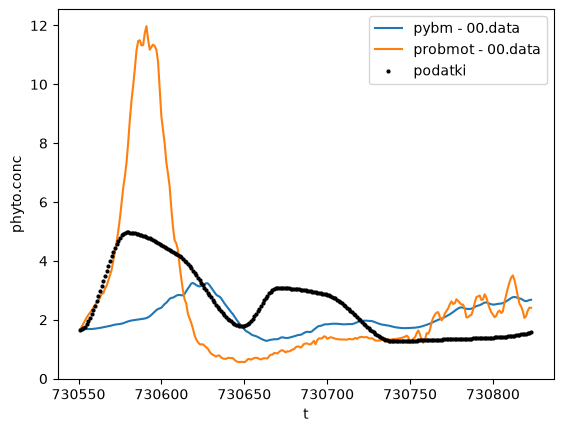

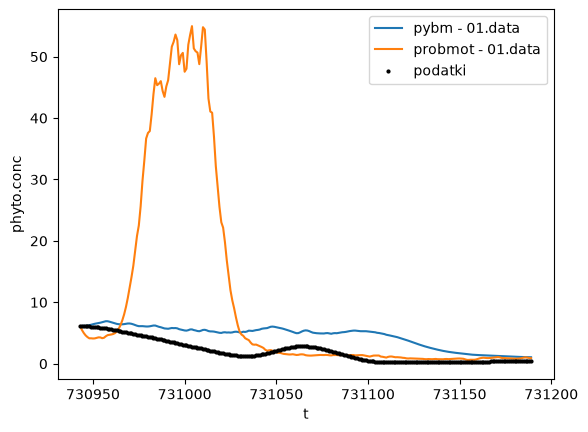

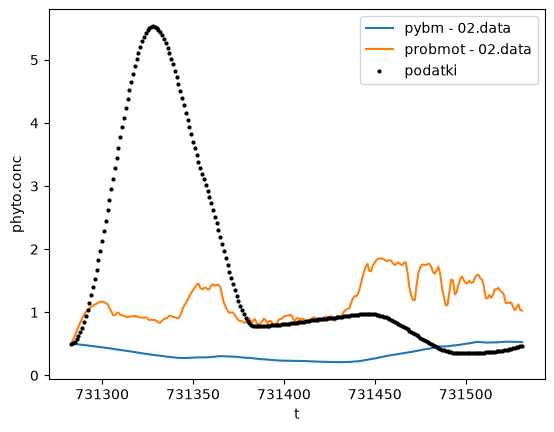

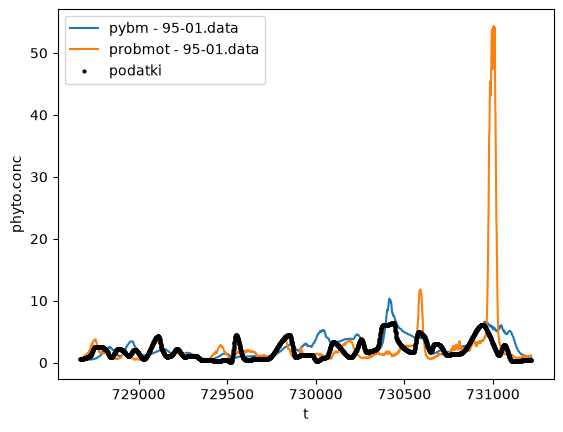

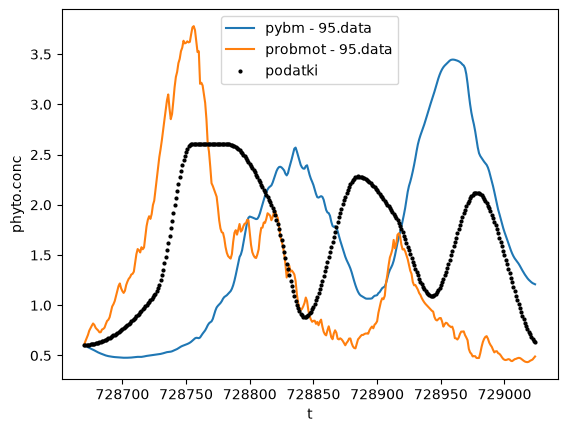

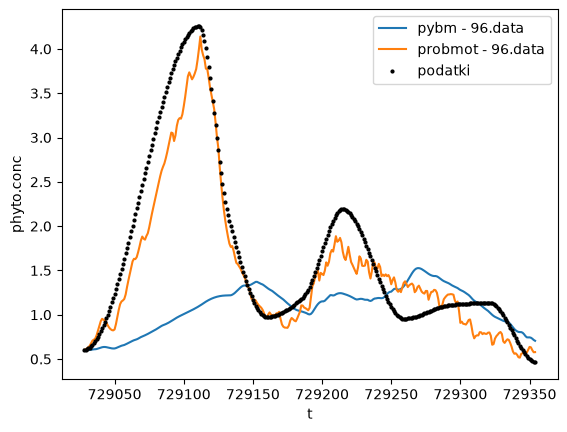

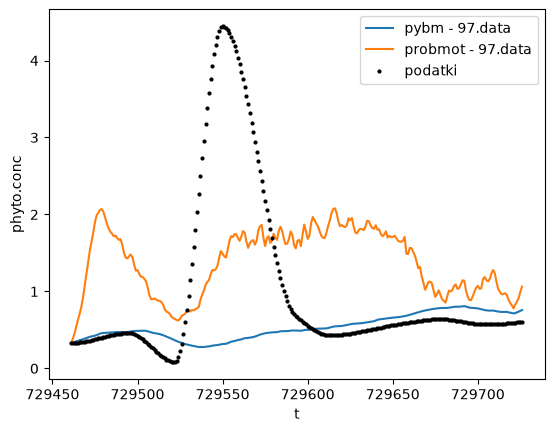

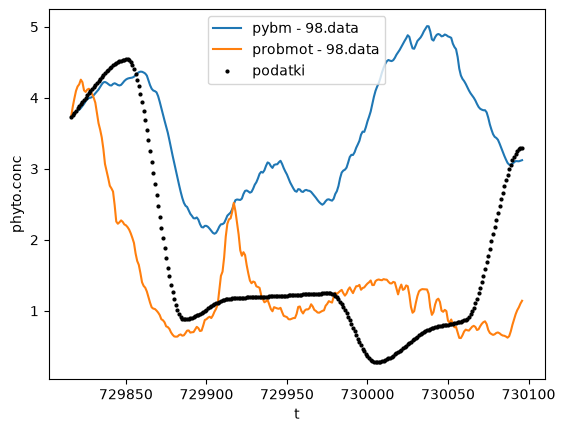

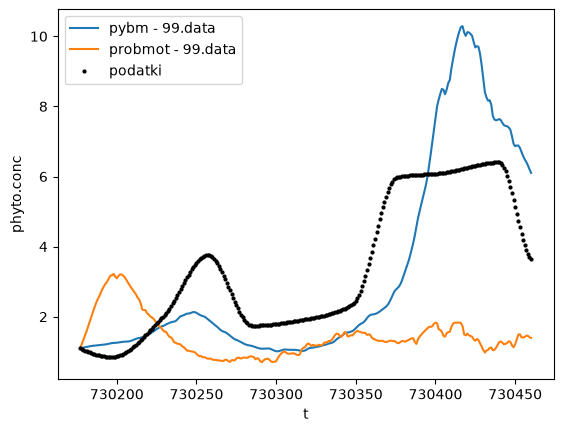

In [38]:
from pybm.model import Context
import matplotlib.pyplot as plt
import numpy as np
from pybm.simulate.trajectory import simulate
from pybm.simulate.initials import get_ctx

model_probmot = probmot_results.best_model
model_pybm = model

model_probmot.switch_engine("scipy")
model_pybm.switch_engine("scipy")

# Prejšnja `set_initial_conditions` je klicala `var(t0)` brez `ctx` (zato TypeError) - in tudi če bi
# ctx dodali, bi za ALGEBRAIČNE spremenljivke (nutrientLim, growthRate, ...) to bila napačna
# vrednost, ker te nimajo `.data` - njihova "trenutna vrednost" ob t0 sploh ni definirana, dokler
# se ne poračuna iz stanja. `get_ctx()` to reši pravilno: eksogene/state spremenljivke postavi iz
# podatkov pri t0, algebraične pa na harmless placeholder 0.0 - `simulate()` jih itak vsak časovni
# korak na novo poračuna iz trenutnega stanja (`_settle_algebraic`), zato njihova začetna vrednost
# tu sploh ni pomembna.

# test on different datasets
datasets = ["00.data", "01.data", "02.data", "95-01.data", "95.data", "96.data", "97.data", "98.data", "99.data"]
for dataset in datasets:
    plt.figure()
    for name, _model in (("pybm", model_pybm), ("probmot", model_probmot)):
        set_data(f"./data/{dataset}", _model)

        t_eval = _model.vars["phyto.conc"].data.t
        consts = results_torch.consts if name == "pybm" else probmot_results.best_consts

        ctx = get_ctx(_model, t=float(t_eval[0]))
        ctx = Context(vars=ctx["vars"], consts=np.asarray(consts, dtype=float))

        sol = simulate(_model, t_eval, ctx)
        phyto_idx = _model.vars["phyto.conc"].index_in_ctx
        plt.plot(t_eval, sol.y[phyto_idx], label=f"{name} - {dataset}")
    plt.plot(t_eval, _model.vars["phyto.conc"].data(t_eval), "o", color="black", markersize=2, label="podatki")
    plt.xlabel("t")
    plt.ylabel("phyto.conc")
    plt.legend()
    plt.show()

In [39]:
# Primerjava naših rezultatov (decompose=True) s ProBMoT-ovim že rešenim modelom (BledComplete.pbm)
#
# BledComplete.pbm nima strukturne dvoumnosti - konstante so že rešene, prebrane direktno iz
# datoteke (glej TRUE_VALUES zgoraj) - to je ProBMoT-ov "rezultat" za ta problem. Obe simulaciji
# poganjamo z istimi eksogenimi podatki (VAR_TO_COLUMN) in istim, dejansko izmerjenim začetnim
# pogojem (simulate(..., initial=None) prebere phyto.conc iz podatkov pri t[0]), da je primerjava
# poštena - razlike v spodnjih trajektorijah izhajajo samo iz razlik v strukturi/konstantah, ne iz
# drugačnih vhodov. phyto.conc je edina diferencialna (state) spremenljivka v tem modelu - vse
# ostalo (ortp/no/silica/daph/env.*) je eksogena vhodna podatkovna vrsta - zato ima simulate() samo
# EN stolpec (sim.vars == ["conc"]).
#
# Imena konstant se med najino iskano strukturo in BledComplete NE ujemajo nujno (najina struktura
# je bila izbrana arbitrarno izmed 1344 kandidatov, glej opombo ob TRUE_VALUES) - zato primerjamo
# na nivoju SIMULIRANE TRAJEKTORIJE (structure-agnostic), ne posameznih konstant po imenu.
import numpy as np
import matplotlib.pyplot as plt
from pybm.estimate.analysis_torch import simulate

probmot_model = load_model("./probmot/BledComplete.pbm", library).induce()[0]
for varname, column in VAR_TO_COLUMN.items():
    probmot_model.vars[varname].data = TimeSeries(t, df[column].values[: len(t)])
probmot_model.switch_engine("torch")

probmot_consts = np.zeros(len(probmot_model.consts))
for name, const in probmot_model.consts.items():
    probmot_consts[const.index_in_ctx] = const.initial_value

ours = simulate(results_decomp.best_model, t, results_torch.consts)
probmot = simulate(probmot_model, t, probmot_consts)

ours_phyto = ours.y[0]
probmot_phyto = probmot.y[0]
data_phyto = df["phyto"].values[: len(t)]

ours_mse = float(np.mean((ours_phyto - data_phyto) ** 2))
probmot_mse = float(np.mean((probmot_phyto - data_phyto) ** 2))
print(f"MSE (nova metoda, decompose=True): {ours_mse:.4g}")
print(f"MSE (ProBMoT, BledComplete):          {probmot_mse:.4g}")


plot_lenght=50
plt.figure(figsize=(10, 5))
plt.plot(t, data_phyto, "o", color="black", markersize=3, label="podatki (phyto.conc)")
plt.plot(t, ours_phyto, "-", linewidth=2, label=f"nova metoda (decompose=True), MSE={ours_mse:.3g}")
plt.plot(t, probmot_phyto, "--", linewidth=2, label=f"ProBMoT (BledComplete), MSE={probmot_mse:.3g}")
plt.xlabel("t")
plt.ylabel("phyto.conc")
plt.title("Simulirane trajektorije: podatki vs. nova metoda vs. ProBMoT")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'VAR_TO_COLUMN' is not defined

## Pravi ProBMoT tek (`exhaustive_search`, `taskInduce_fix.xml`)

To ni teklo v tem notebooku - to je pravi ProBMoT (Java) `exhaustive_search`, pognan ločeno na
`/home/urhp/Documents/probmot/examples/aquatic/` (isti `BledIncompleteStructure.pbm`/
`AquaticEcosystem.pbl`, a na **`96.data`**, ne `00.data` kot mi!). Tekel je ~22h (19.8. 11:42 -
20.8. 9:34), rezultati so v `out/induction/`.

Dve pomembni ugotovitvi pri branju rezultatov:

1. **`Models.out` vsebuje vseh 1344 kandidatov** (isto število kot naša `decompose=True`
   enumeracija - lep neodvisen check, da se najin strukturni prostor ujema z ProBMoT-ovim), vsak s
   svojo `Train Error :RMSEMultiDataset`. Najboljši (najnižji) med vsemi 1344 je **Model #939,
   RMSE = 0.2495** - NE tisti, izvožen v `out/induction/simulation/Model#0.sim`! Ta ima
   RMSE = 0.843 - preveril sem (re-računanje RMSE direktno iz `.sim` datoteke proti `96.data`) in
   se natančno ujema z zadnjim ("Model #1344") kandidatom v `Models.out`, ne z najboljšim. Torej
   `Model#0.sim` je samo zadnji OVREDNOTEN kandidat, ne najboljši - artefakt orodja/naloge (task
   XML ni prosil za izvoz najboljšega), ne nekaj namernega.
2. Zapis Modela #939 v `Models.out` ima precej `null` konstant (`taskInduce_fix.xml` ima prazen
   `<output><constants>`, zato ProBMoT večine ne izpiše nazaj). Preveril sem v knjižnici
   (`AquaticEcosystem.pbl`), da so vse dejansko STRUKTURNO neuporabljene v tej izbrani veji - npr.
   `LinearTempGrowthLim`-ova enačba je `pop.tempGrowthLim = env.temperature / refTemp` - sploh ne
   bere `minTemp`/`optTemp`; izbrani `NoNutrientLim` je `pp.nutrientLim = 1` - ne bere
   `alpha`/`halfSaturation`. Torej sem jih varno nadomestil s placeholder `1.0` in model shranil kot
   [`probmot/BledInducedBest939.pbm`](probmot/BledInducedBest939.pbm), da ga lahko naložimo nazaj v
   pybm in simuliramo/primerjamo spodaj.

Opomba: pybm-ova (scipy `solve_ivp`) re-simulacija te iste strukture/konstant na `96.data` da
nekoliko drugačen RMSE kot ProBMoT-ov lastni (CVODE) - pričakovano (drug solver), ne napaka v
konverziji; glej izpis spodaj.

In [ ]:
PROBMOT_RUN_RMSE = 0.24951723741130502  # ProBMoT-ovo lastno "Train Error :RMSEMultiDataset" za Model #939 (Models.out)

# Konstante, ki so bile v Models.out izvožene kot "null" (glej markdown zgoraj) - v tej strukturni
# veji jih ustrezna enačba dokazano ne bere (NoNutrientLim/LinearTempGrowthLim), zato so v
# BledInducedBest939.pbm nadomeščene s placeholder 1.0, NE s ProBMoT-ovo dejansko fitano vrednostjo.
UNUSED_PROBMOT_CONSTS = {
    "ortp.halfSaturation", "ortp.alpha", "no.halfSaturation", "no.alpha",
    "silica.halfSaturation", "silica.alpha", "daph.assimilationCoeff",
    "nutrientPPInteraction.growth.tempGrowthLim689.minTemp",
    "nutrientPPInteraction.growth.tempGrowthLim689.optTemp",
    "feedsOn.tempGrowthInfluence70.minTemp", "feedsOn.tempGrowthInfluence70.optTemp",
}

probmot_best_model = load_model("./probmot/BledInducedBest939.pbm", library).induce()[0]

df96 = pd.read_csv("./data/00.data", sep=" ")
t96 = df96["t"].values
for varname, column in VAR_TO_COLUMN.items():
    probmot_best_model.vars[varname].data = TimeSeries(t96, df96[column].values)

probmot_best_model.switch_engine("scipy")
ctx_probmot_best = get_ctx(probmot_best_model, t=float(t96[0]))
sol_probmot_best = simulate_full(probmot_best_model, t96, ctx_probmot_best)

phyto_idx_best = probmot_best_model.vars["phyto.conc"].index_in_ctx
sim_phyto_best = sol_probmot_best.y[phyto_idx_best]
data_phyto_96 = df96["phyto"].values
rmse_pybm_resim = float(np.sqrt(np.mean((sim_phyto_best - data_phyto_96) ** 2)))

print(f"ProBMoT-ovo lastno poročano RMSE (Model #939, iz Models.out, CVODE solver): {PROBMOT_RUN_RMSE:.4g}")
print(f"RMSE iste strukture/konstant, re-simulirane v pybm (scipy solve_ivp):         {rmse_pybm_resim:.4g}")

plt.figure(figsize=(10, 5))
plt.plot(t96, data_phyto_96, "o", color="black", markersize=3, label="podatki (96.data, phyto.conc)")
plt.plot(t[:plot_lenght], ours_phyto[:plot_lenght], "-", linewidth=2, label=f"najin rezultat (decompose=True), MSE={ours_mse:.3g}")
plt.plot(t96, sim_phyto_best, "-", linewidth=2, color="tab:green",
         label=f"ProBMoT najboljši (Model #939 / 1344), pybm-RMSE={rmse_pybm_resim:.3g}")
plt.xlabel("t")
plt.ylabel("phyto.conc")
plt.title("ProBMoT exhaustive_search na 96.data: najboljši od 1344 kandidatov")
plt.legend()
plt.tight_layout()
plt.show()

print("\nKonstante ProBMoT-ovega najboljšega modela (Model #939) - '(neuporabljena)' za tiste, ki so bile")
print("v Models.out izvožene kot null in sem jih zato nadomestil s placeholder 1.0 (glej opombo zgoraj):")
for name, const in probmot_best_model.consts.items():
    flag = "" if name not in UNUSED_PROBMOT_CONSTS else "  (neuporabljena, placeholder)"
    print(f"  {name}: {const.initial_value:.6g}{flag}")

NameError: name 'get_ctx' is not defined